# MiniTienda - Registro y Analisis de Ventas

**Estudiante:** _____________________
**Curso:** _____________________
**Fecha:** Agosto 2026

Este notebook implementa y prueba el desafio **MiniTienda**: catalogo con
tuplas, precios/stock con diccionarios, registro de ventas con listas y
pandas, persistencia en CSV, metricas con NumPy, grafico de ingresos con
Matplotlib y menu interactivo con `while`. Incluye la ejecucion de los
**Retos A, B, C y D**.

## 0. Importacion de librerias y definicion del modulo `mini_tienda`
El codigo completo del programa (funciones modulares) se encuentra en `mini_tienda.py`. A continuacion se importa y se listan sus componentes.

In [1]:
import mini_tienda as mt
import pandas as pd
import numpy as np

print("Funciones disponibles en mini_tienda:")
for nombre in dir(mt):
    if not nombre.startswith("_") and callable(getattr(mt, nombre)):
        print(" -", nombre)

Funciones disponibles en mini_tienda:
 - actualizar_precio_stock
 - agregar_producto
 - buscar_producto
 - calcular_descuento
 - calcular_metricas
 - datetime
 - escribir_log
 - graficar_ingresos
 - guardar_ventas_csv
 - leer_ventas_csv
 - menu
 - mostrar_catalogo
 - registrar_venta
 - validar_producto


## 1. Catalogo (tuplas) y diccionarios de precios/stock
`CATALOGO` es una **tupla de tuplas** `(id, nombre, categoria)`. `PRECIOS` y `STOCK` son **diccionarios** `id -> valor`.

In [2]:
catalogo = mt.CATALOGO
precios = dict(mt.PRECIOS)
stock = dict(mt.STOCK)
ventas = []       # lista (buffer) de ventas
ids_venta = []     # lista de IDs de venta

print("Tipo de catalogo:", type(catalogo))
print("Tipo de precios:", type(precios))
print("Tipo de stock:", type(stock))
mt.mostrar_catalogo(catalogo, precios, stock)

Tipo de catalogo: <class 'tuple'>
Tipo de precios: <class 'dict'>
Tipo de stock: <class 'dict'>

ID  PRODUCTO          CATEGORIA     PRECIO    STOCK 
1   Arroz 1kg         Abarrotes     $1.25     50    
2   Aceite 1L         Abarrotes     $3.10     40    
3   Leche 1L          Lacteos       $0.95     60    
4   Pan Molde         Panaderia     $2.20     35    
5   Detergente 1kg    Limpieza      $4.50     25    


## 2. Registro de ventas (listas + Pandas)
Se registran **14 intentos de venta** (mas de las 10 minimas requeridas), incluyendo dos intentos invalidos para probar el manejo de errores: un `producto_id` inexistente (99) y una `cantidad` negativa.

In [3]:
intentos_venta = [
    (1, 5), (2, 3), (3, 12), (4, 2), (5, 1),
    (1, 10), (2, 4), (99, 2), (3, 6), (4, 15),
    (5, 2), (2, -3), (1, 3), (3, 4),
]

for pid, cant in intentos_venta:
    mt.registrar_venta(pid, cant, ventas, ids_venta, catalogo, precios, stock)

print(f"\nVentas exitosas: {len(ventas)}")
print(f"IDs de venta: {ids_venta}")

Venta registrada -> ID 1: 5 x Arroz 1kg = $6.25 (descuento $0.00)
Venta registrada -> ID 2: 3 x Aceite 1L = $9.30 (descuento $0.00)
Venta registrada -> ID 3: 12 x Leche 1L = $10.83 (descuento $0.57)
Venta registrada -> ID 4: 2 x Pan Molde = $4.40 (descuento $0.00)
Venta registrada -> ID 5: 1 x Detergente 1kg = $4.50 (descuento $0.00)
Venta registrada -> ID 6: 10 x Arroz 1kg = $11.88 (descuento $0.62)
Venta registrada -> ID 7: 4 x Aceite 1L = $12.40 (descuento $0.00)
Error: INTENTO FALLIDO: producto_id=99 no existe en el catalogo.
Venta registrada -> ID 8: 6 x Leche 1L = $5.70 (descuento $0.00)
Venta registrada -> ID 9: 15 x Pan Molde = $31.35 (descuento $1.65)
Venta registrada -> ID 10: 2 x Detergente 1kg = $9.00 (descuento $0.00)
Error: INTENTO FALLIDO: cantidad invalida (-3) para producto_id=2.
Venta registrada -> ID 11: 3 x Arroz 1kg = $3.75 (descuento $0.00)
Venta registrada -> ID 12: 4 x Leche 1L = $3.80 (descuento $0.00)

Ventas exitosas: 12
IDs de venta: [1, 2, 3, 4, 5, 6, 7, 8,

## Reto A: agregar producto nuevo y actualizar precio/stock
Como `catalogo` es una tupla (inmutable), `agregar_producto` construye y retorna una **tupla nueva** concatenando el producto agregado. `precios` y `stock` se actualizan in-place por ser diccionarios.

In [4]:
catalogo = mt.agregar_producto(
    catalogo, precios, stock,
    producto_id=6, nombre="Yogurt 1L", categoria="Lacteos",
    precio=2.75, stock_inicial=30,
)
mt.actualizar_precio_stock(precios, stock, producto_id=6, nuevo_precio=2.90, nuevo_stock=28)

# Ventas del producto nuevo (una de ellas dispara el descuento del Reto C)
mt.registrar_venta(6, 11, ventas, ids_venta, catalogo, precios, stock)
mt.registrar_venta(6, 2, ventas, ids_venta, catalogo, precios, stock)

mt.mostrar_catalogo(catalogo, precios, stock)

Producto agregado: (6, 'Yogurt 1L', 'Lacteos') | precio=$2.75 stock=30
Producto 6 actualizado -> precio=2.9, stock=28
Venta registrada -> ID 13: 11 x Yogurt 1L = $30.31 (descuento $1.59)
Venta registrada -> ID 14: 2 x Yogurt 1L = $5.80 (descuento $0.00)

ID  PRODUCTO          CATEGORIA     PRECIO    STOCK 
1   Arroz 1kg         Abarrotes     $1.25     32    
2   Aceite 1L         Abarrotes     $3.10     33    
3   Leche 1L          Lacteos       $0.95     38    
4   Pan Molde         Panaderia     $2.20     18    
5   Detergente 1kg    Limpieza      $4.50     22    
6   Yogurt 1L         Lacteos       $2.90     15    


## Reto C: descuento por volumen (>= 10 unidades -> 5%)
La funcion `calcular_descuento` se invoca dentro de `registrar_venta`. Se observa arriba que las ventas con `cantidad >= 10` (ID 3, 6, 9 y 13) muestran un descuento distinto de cero.

In [5]:
df_temp = pd.DataFrame(ventas)
df_temp[df_temp["cantidad"] >= 10][["id_venta", "producto_nombre", "cantidad", "descuento", "subtotal"]]

    id_venta producto_nombre  cantidad  descuento  subtotal
2          3        Leche 1L        12       0.57     10.83
5          6       Arroz 1kg        10       0.62     11.88
8          9       Pan Molde        15       1.65     31.35
12        13       Yogurt 1L        11       1.59     30.31

## 3. Guardar ventas en CSV (Pandas)
El buffer de ventas (lista de diccionarios) se convierte a `DataFrame` y se persiste con `to_csv`.

In [6]:
df_guardado = mt.guardar_ventas_csv(ventas, mt.VENTAS_CSV)
df_guardado

14 ventas guardadas en 'ventas.csv'.


    id_venta  producto_id producto_nombre  cantidad  precio_unitario  descuento  subtotal                fecha
0          1            1       Arroz 1kg         5             1.25       0.00      6.25  2026-08-20 02:49:37
1          2            2       Aceite 1L         3             3.10       0.00      9.30  2026-08-20 02:49:37
2          3            3        Leche 1L        12             0.95       0.57     10.83  2026-08-20 02:49:37
3          4            4       Pan Molde         2             2.20       0.00      4.40  2026-08-20 02:49:37
4          5            5  Detergente 1kg         1             4.50       0.00      4.50  2026-08-20 02:49:37
5          6            1       Arroz 1kg        10             1.25       0.62     11.88  2026-08-20 02:49:37
6          7            2       Aceite 1L         4             3.10       0.00     12.40  2026-08-20 02:49:37
7          8            3        Leche 1L         6             0.95       0.00      5.70  2026-08-20 02:49:37
8

## 4. Leer ventas desde CSV (manejo de errores: archivo inexistente)
`leer_ventas_csv` usa `try/except/else/finally`. Primero se prueba con una ruta que no existe (error controlado) y luego con la ruta real.

In [7]:
df_error = mt.leer_ventas_csv("archivo_que_no_existe.csv")
print("df_error:", df_error)

df = mt.leer_ventas_csv(mt.VENTAS_CSV)
df.head(14)

Error: No se encontro el archivo 'archivo_que_no_existe.csv'.
Fin del intento de lectura de ventas.csv.
df_error: None
Archivo 'ventas.csv' leido correctamente (14 filas).
Fin del intento de lectura de ventas.csv.


    id_venta  producto_id producto_nombre  cantidad  precio_unitario  descuento  subtotal                fecha
0          1            1       Arroz 1kg         5             1.25       0.00      6.25  2026-08-20 02:49:37
1          2            2       Aceite 1L         3             3.10       0.00      9.30  2026-08-20 02:49:37
2          3            3        Leche 1L        12             0.95       0.57     10.83  2026-08-20 02:49:37
3          4            4       Pan Molde         2             2.20       0.00      4.40  2026-08-20 02:49:37
4          5            5  Detergente 1kg         1             4.50       0.00      4.50  2026-08-20 02:49:37
5          6            1       Arroz 1kg        10             1.25       0.62     11.88  2026-08-20 02:49:37
6          7            2       Aceite 1L         4             3.10       0.00     12.40  2026-08-20 02:49:37
7          8            3        Leche 1L         6             0.95       0.00      5.70  2026-08-20 02:49:37
8

## 5. Metricas con NumPy + agrupacion con Pandas
`calcular_metricas` convierte la columna `subtotal` en un **arreglo NumPy** y calcula `mean`, `std` y `sum`. La division para el ingreso por unidad esta protegida con `try/except ZeroDivisionError`. El agrupamiento por producto usa `DataFrame.groupby`.

In [8]:
resumen, ingresos_por_producto = mt.calcular_metricas(df)
resumen


--- Metricas generales (NumPy) ---
Ingreso total:        $149.27
Promedio por venta:   $10.66
Desviacion estandar:  $8.71
Ingreso por unidad:   $1.87

--- Ingresos por producto (Pandas groupby) ---
  Yogurt 1L          $36.11   (13 unidades)
  Pan Molde          $35.75   (17 unidades)
  Arroz 1kg          $21.88   (18 unidades)
  Aceite 1L          $21.70   (7 unidades)
  Leche 1L           $20.33   (22 unidades)
  Detergente 1kg     $13.50   (3 unidades)


{'total': np.float64(149.27), 'promedio': np.float64(10.662142857142857), 'desviacion': np.float64(8.713531495464338), 'ingreso_por_unidad': np.float64(1.8658750000000002)}

In [9]:
ingresos_por_producto

producto_nombre
Yogurt 1L         36.11
Pan Molde         35.75
Arroz 1kg         21.88
Aceite 1L         21.70
Leche 1L          20.33
Detergente 1kg    13.50

## 6. Grafico de ingresos por producto (Matplotlib)

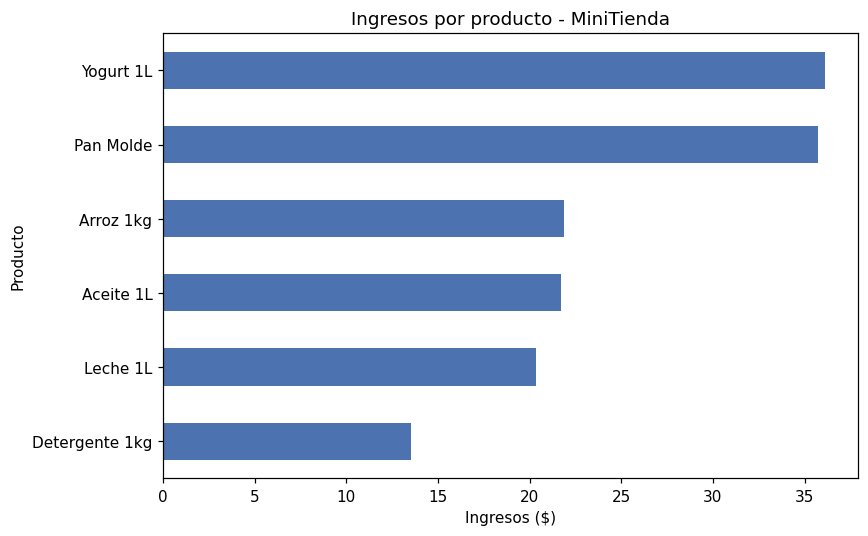

In [10]:
fig = mt.graficar_ingresos(ingresos_por_producto)
fig

## Reto B: exportar grafico a PNG (`plt.savefig`)
Corresponde a la opcion **6) Exportar grafico a PNG** del menu.

In [11]:
fig2 = mt.graficar_ingresos(ingresos_por_producto, exportar=True, filename="ingresos.png")
import os
print("Archivo generado:", os.path.exists("ingresos.png"), "-", os.path.getsize("ingresos.png"), "bytes")

Grafico exportado como 'ingresos.png'.
Archivo generado: True - 34963 bytes


## Reto D: registro de intentos fallidos en `log.txt`
Cada intento de venta con un `producto_id` que no existe en el catalogo (y otros errores de validacion) se escribe en `log.txt` ademas de rechazarse en memoria.

In [12]:
with open(mt.LOG_TXT, "r", encoding="utf-8") as f:
    print(f.read())

[2026-08-20 02:49:36] INTENTO FALLIDO: producto_id=99 no existe en el catalogo.
[2026-08-20 02:49:36] INTENTO FALLIDO: cantidad invalida (-3) para producto_id=2.
[2026-08-20 02:49:36] No se encontro el archivo 'archivo_que_no_existe.csv'.
[2026-08-20 02:49:37] INTENTO FALLIDO: producto_id=99 no existe en el catalogo.
[2026-08-20 02:49:37] INTENTO FALLIDO: cantidad invalida (-3) para producto_id=2.
[2026-08-20 02:49:37] No se encontro el archivo 'archivo_que_no_existe.csv'.



## Prueba de division por cero controlada
Se simula un `DataFrame` de ventas con `cantidad` en cero para forzar la rama `except ZeroDivisionError` de `calcular_metricas` sin que el programa se detenga.

In [13]:
df_cero = pd.DataFrame([
    {"id_venta": 1, "producto_id": 1, "producto_nombre": "Prueba",
     "cantidad": 0, "precio_unitario": 5.0, "descuento": 0.0, "subtotal": 0.0,
     "fecha": "2026-01-01"}
])
resumen_cero, _ = mt.calcular_metricas(df_cero)
resumen_cero

Error controlado: Division por cero al calcular ticket promedio por unidad.

--- Metricas generales (NumPy) ---
Ingreso total:        $0.00
Promedio por venta:   $0.00
Desviacion estandar:  $0.00
Ingreso por unidad:   $0.00

--- Ingresos por producto (Pandas groupby) ---
  Prueba             $0.00   (0 unidades)


{'total': np.float64(0.0), 'promedio': np.float64(0.0), 'desviacion': np.float64(0.0), 'ingreso_por_unidad': 0.0}

## Validacion de entradas invalidas (no numericas)
Simulacion de la rama `try/except ValueError` del menu cuando el usuario ingresa texto en vez de un numero para `producto_id` o `cantidad`.

In [14]:
entrada_usuario = "abc"
try:
    pid = int(entrada_usuario)
except ValueError:
    print(f"Error: '{entrada_usuario}' no es un numero entero valido. "
          f"Se solicitara el dato nuevamente (simulado).")

Error: 'abc' no es un numero entero valido. Se solicitara el dato nuevamente (simulado).


## Menu interactivo (bucle `while`)

La funcion `mt.menu()` implementa el programa de consola completo con
`while True`, `if/elif/else`, `try/except/else/finally`, `break` y
`continue`. Al ejecutarse en una terminal real, `input()` solicita cada
opcion al usuario. En este notebook se muestra el codigo fuente de la
funcion para evidenciar su estructura (no se ejecuta interactivamente
porque Jupyter/Colab no tiene una consola de teclado en el momento de
evaluar automaticamente esta celda).

In [15]:
import inspect
print(inspect.getsource(mt.menu))

def menu():
    catalogo = CATALOGO
    precios = dict(PRECIOS)
    stock = dict(STOCK)
    ventas = []          # buffer de ventas (lista)
    ids_venta = []        # lista de IDs

    opciones_validas = {"1", "2", "3", "4", "5", "6", "7", "0"}

    while True:
        print("\n===== MENU MINITIENDA =====")
        print("1) Ver catalogo")
        print("2) Registrar venta")
        print("3) Guardar ventas en CSV")
        print("4) Leer ventas desde CSV y ver metricas")
        print("5) Graficar ingresos por producto")
        print("6) Exportar grafico a PNG")        # Reto B
        print("7) Agregar producto al catalogo")   # Reto A
        print("0) Salir")

        opcion = input("Seleccione una opcion: ").strip()

        if opcion not in opciones_validas:
            print("Opcion invalida, intente de nuevo.")
            continue

        try:
            if opcion == "1":
                mostrar_catalogo(catalogo, precios, stock)

            elif opcion == "2":
          

## Preguntas del entregable

**1) Que parte la hizo Pandas? Que parte NumPy?**

- **Pandas** se uso para: construir el `DataFrame` de ventas a partir de la
  lista de diccionarios (`pd.DataFrame(ventas)`), guardar y leer el CSV
  (`to_csv` / `read_csv`), y agrupar los ingresos y unidades por producto
  con `groupby("producto_nombre").sum()`.
- **NumPy** se uso para calcular las metricas agregadas sobre el arreglo de
  subtotales: `np.mean`, `np.std`, `np.sum`, y la division protegida para
  el ingreso por unidad vendida.

**2) Donde usaste try/except y por que?**

- En `leer_ventas_csv`: `try/except FileNotFoundError` y
  `except pd.errors.EmptyDataError`, con `else` para confirmar la lectura
  correcta y `finally` para dejar constancia de que el intento de lectura
  termino, exista o no el archivo.
- En `calcular_metricas`: `try/except ZeroDivisionError` para evitar que el
  programa se caiga si no hay unidades vendidas al calcular el ingreso por
  unidad.
- En `registrar_venta` (via `escribir_log`) y en el `menu()`: validaciones
  de `producto_id` inexistente y `cantidad` invalida, y un `try/except
  Exception` general alrededor de cada opcion del menu para capturar
  errores inesperados sin cerrar el programa.
- En el menu, al convertir la entrada de teclado a `int`/`float`:
  `try/except ValueError` para evitar que un texto no numerico rompa el
  programa.

**3) Que estructuras son tuplas, listas y diccionarios en el codigo?**

- **Tuplas:** `CATALOGO` (tupla de tuplas `(id, nombre, categoria)`); cada
  producto individual devuelto por `buscar_producto` tambien es una tupla.
- **Listas:** `ventas` (buffer de diccionarios de venta) e `ids_venta`
  (lista de IDs de venta); tambien `intentos_venta` en las pruebas.
- **Diccionarios:** `PRECIOS` (`id -> precio`), `STOCK` (`id -> cantidad`),
  y cada venta individual dentro de `ventas` es un diccionario con las
  columnas de la venta.